# ALS_LLRF_MTS test on LBL208_LLRF

* DAC Fs = 7GHz
* ADC Fs = 3.5GHz
---

### Preparation from a PYNQ 3.0.1 image:

Run installation script: `./pynq_llrf/install.sh`.

In [1]:
%cd /home/xilinx/jupyter_notebooks/pynq_llrf

/home/xilinx/jupyter_notebooks/pynq_llrf


In [ ]:
from mimo_mts.overlay import MimoMtsOverlay
import numpy as np

%load_ext autoreload
%autoreload 2

##  Configure SI570 to 156.1375 MHz

Due to EVG referece clock is 499.64 / 4 MHz, line rate is 2498.2 MHz.
GTY reference clock needs to be 2498.2 / 8 = 156.1375 MHz.

In [3]:
from mimo_mts.utils.config_si570 import SI570
with SI570() as si570:
    si570.set_freq(156.1375)

In [ ]:
ol_config = {
    'bitfile_name': 'als_llrf_mts.bit',
    'board': 'LBL208_DAC2X',
    'lmk_tcs': 'mimo_mts/utils/clk104/LMK04828_500M_CLKin0_DIST_1.25M_SYSREF.tcs',
    'lmxadc_tcs': 'mimo_mts/utils/clk104/LMX2594_3.5G.tcs',
    'lmxdac_tcs': 'mimo_mts/utils/clk104/LMX2594_7G.tcs',
    'si570_freq_mhz': 156.1375,
    'verbose': True
}

In [ ]:
ol = MimoMtsOverlay(**ol_config)

In [6]:
ol.evr.check_frequencies()

In [7]:
ol.evr

GT EVR GTY:      ['xilinx.com:module_ref:axil_evr:1.0']
Event count:     37
GTY ref freq:    156.1371 MHz
GTY RX freq:     124.9107 MHz
Timestamp valid: True
Timestamp:       479461731
GTY status:      0x7
RX aligned:      True

---

### Test deterministic latency incurred due to alignment
Every reboot should result in the same latency and offet \
Example: \
DAC Latency: 544, Offset: 0 \
ADC Latency:  96, Offset: 0

In [8]:
for i in range(4):
    print(f"DAC Tile {i} Latency: {ol.rfdc.mts_dac_config.Latency[i]:3d}, "
          f"Offset: {ol.rfdc.mts_dac_config.Offset[i]}\n"
          f"ADC Tile {i} Latency: {ol.rfdc.mts_adc_config.Latency[i]:3d}, "
          f"Offset: {ol.rfdc.mts_adc_config.Offset[i]}")

DAC Tile 0 Latency: 544, Offset: 4
ADC Tile 0 Latency:  96, Offset: 8
DAC Tile 1 Latency: 544, Offset: 4
ADC Tile 1 Latency:  96, Offset: 8
DAC Tile 2 Latency: 544, Offset: 4
ADC Tile 2 Latency:  96, Offset: 8
DAC Tile 3 Latency: 544, Offset: 4
ADC Tile 3 Latency:  96, Offset: 8


# Configure trigger

EVR, 1 Hz

In [9]:
ol.rf_control.register_map.trig_period = 250e6
ol.rf_control.register_map.trig_sel = 1  # EVR trigger
ol.rf_control.register_map.trig_delay = 0
ol.rf_control.register_map.trig_divide = 1
ol.rf_control.register_map.dac_enable = 1
ol.rf_control.register_map.pulse_length = 4096
ol.rf_control.register_map.amp_loop_setpoint = 0

There is a 3GHz band-pass filter between dac0 and adc0 loopback.

* Set DAC baseband waveform as DC
* Set DAC Mixer frequency to 3GHz for up conversion
* Set ADC Mixer frequency to 0Hz to check RF waveform

In [10]:
dac_i = np.ones(ol.dac_player.size//2, dtype=np.int16) * 32767
dac_q = np.zeros_like(dac_i)

In [11]:
ol.write_dac_iq_buf(dac_i, dac_q)

In [12]:
from mimo_mts.utils.plot import plot_complex_wfm

fs = ol.board.adc_sampling_rate
start = 1172 # start of the signal
print(f'RF loop back latency: {start/fs * 1e9:.3f} ns')

RF loop back latency: 334.857 ns


In [13]:
ol.set_dac_mixer_dco(3000)

In [14]:
ol.set_adc_mixer_dco(0)

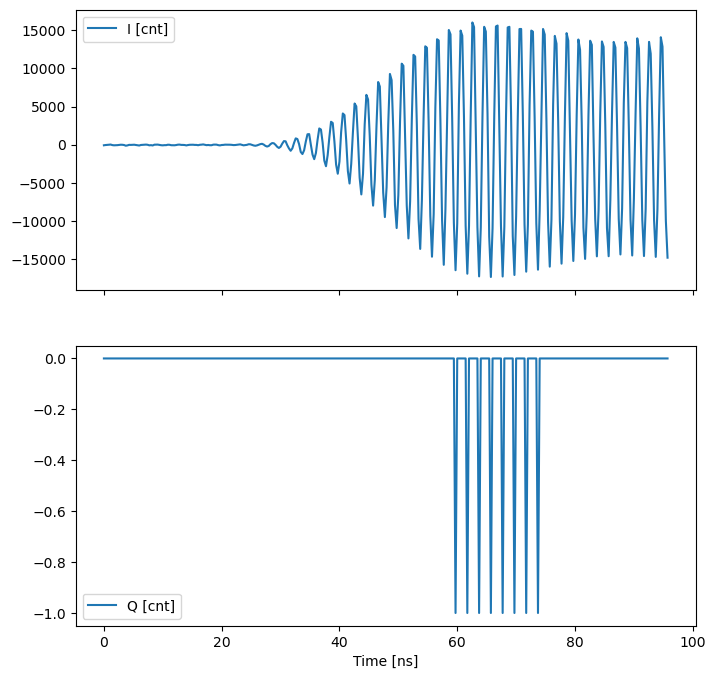

In [15]:
darray_i, darray_q = ol.capture_adc_iq_buf();
cdata = darray_i + 1j*darray_q
plot_complex_wfm(cdata[0, start-80:start+256], fs=fs)

Set ADC Mixer frequency to 3GHz, check I/Q waveform after mixing.

In [16]:
ol.set_adc_mixer_dco(-3000)

In [17]:
darray_i, darray_q = ol.capture_adc_iq_buf();
cdata = darray_i + 1j*darray_q

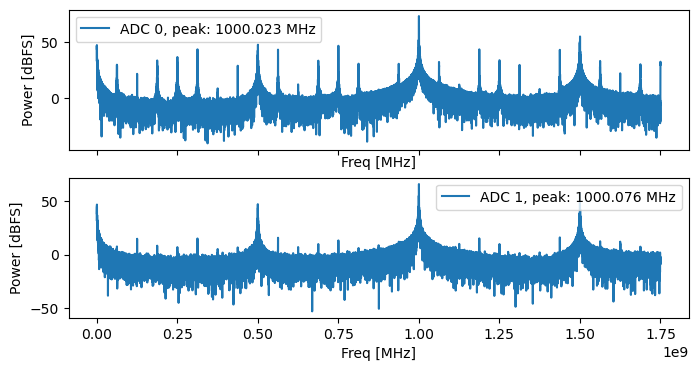

In [18]:
from mimo_mts.utils.plot import plot_adc_psd
plot_adc_psd(np.abs(cdata[:2]), fs=fs)

Average ADC data by 8 samples, as the same to the LLRF DSP, equivalent to a low pass filter to get base band signal.

In [19]:
cdata_dsp = cdata.reshape(8, -1, 8).mean(axis=2)

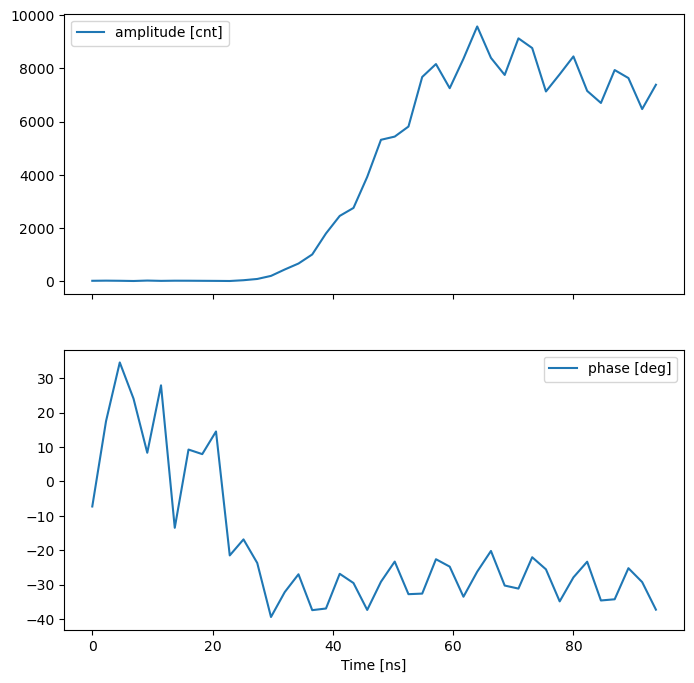

In [20]:
plot_complex_wfm(cdata_dsp[0, (start-80)//8:(start+256)//8], fs=fs/8, mode='ap')

# Disable dac buffer, use llrf amplitude setpoint for CW signal

In [21]:
ol.dac_player[:] = np.zeros(ol.dac_player.size, dtype=np.int16)

In [22]:
ol.rf_control.register_map.amp_loop_setpoint = 32767 / ol.rf_control.tx_gain
ol.rf_control.register_map.phs_loop_setpoint = 0